In [1]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
OUTDIR = Path("segmentation_output")
os.makedirs(OUTDIR, exist_ok=True)

In [3]:
df = pd.read_excel("Dataset_for_Data_Analytics.xlsx")  # your actual DecodeLabs file
print(f"Shape: {df.shape}")
df.head()

Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")
df["has_coupon"] = (df["CouponCode"] != "NoCoupon").astype(int)
df["order_month"] = df["Date"].dt.month
df["order_dayofweek"] = df["Date"].dt.dayofweek
df["cart_fill_ratio"] = df["Quantity"] / df["ItemsInCart"]
df["customer_order_count"] = df.groupby("CustomerID")["OrderID"].transform("count")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,has_coupon,order_month,order_dayofweek,cart_fill_ratio,customer_order_count
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,1,2,0.714286,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,1,8,4,0.666667,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1,2,1,0.625000,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1,10,6,0.200000,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1,5,3,0.500000,1


In [5]:
cat_cols = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

drop_cols = ["OrderID", "Date", "CustomerID", "ShippingAddress", "TrackingNumber"]
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]
X = df_encoded[feature_cols]

print(f"Total features for clustering: {X.shape[1]}")

Total features for clustering: 30


In [6]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA: {X.shape[1]} columns -> 2 components")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA: 30 columns -> 2 components
Explained variance ratio: [0.07779826 0.07652718]
Total variance captured: 15.4%


k=2: inertia=2898.3, silhouette=0.542
k=3: inertia=1427.7, silhouette=0.539
k=4: inertia=962.1, silhouette=0.545
k=5: inertia=636.8, silhouette=0.503
k=6: inertia=515.2, silhouette=0.457
k=7: inertia=399.3, silhouette=0.448


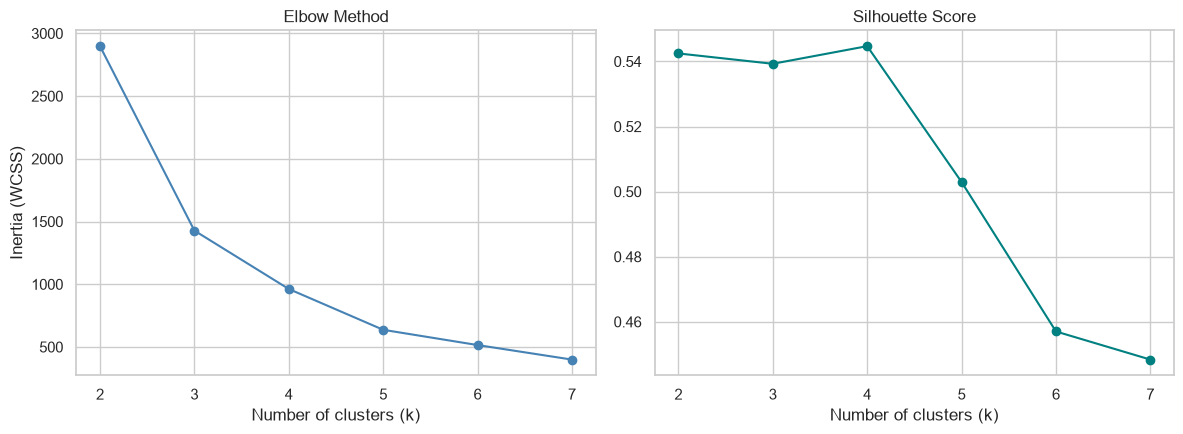


Optimal k by silhouette score: 4


In [7]:
inertias, silhouettes = [], []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(k_range), silhouettes, marker="o", color="teal")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")

plt.tight_layout()
fig.savefig(OUTDIR / "elbow_silhouette.png", dpi=150)
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f"\nOptimal k by silhouette score: {best_k}")

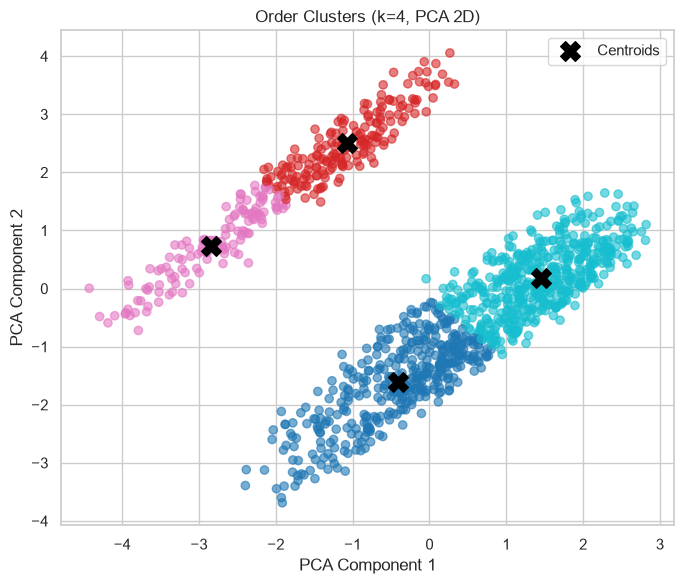

0    397
1    185
2    124
3    494
Name: cluster_size, dtype: int64


In [8]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km.fit_predict(X_pca)
df["cluster"] = labels

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", alpha=0.6)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
           c="black", marker="X", s=200, label="Centroids")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title(f"Order Clusters (k={best_k}, PCA 2D)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / "clusters_pca.png", dpi=150)
plt.show()

print(pd.Series(labels).value_counts().sort_index().rename("cluster_size"))

In [9]:
profile_cols = ["Quantity", "UnitPrice", "TotalPrice", "ItemsInCart", "cart_fill_ratio", "has_coupon"]
profile = df.groupby("cluster")[profile_cols].mean().round(2)
profile["size"] = df.groupby("cluster").size()

for col in ["Product", "PaymentMethod", "ReferralSource"]:
    profile[f"top_{col}"] = df.groupby("cluster")[col].agg(lambda x: x.value_counts().idxmax())

profile.to_csv(OUTDIR / "cluster_personas.csv")
print("Cluster Personas:")
profile

Cluster Personas:


,Quantity,UnitPrice,TotalPrice,ItemsInCart,cart_fill_ratio,has_coupon,size,top_Product,top_PaymentMethod,top_ReferralSource
cluster,,,,,,,,,,
0,4.07,444.83,1755.33,6.83,0.63,1.0,397,Printer,Credit Card,Instagram
1,2.25,284.67,545.83,4.57,0.56,0.0,185,Tablet,Online,Google
2,4.23,433.38,1785.67,7.03,0.64,0.0,124,Chair,Cash,Facebook
3,1.98,292.91,496.95,4.36,0.53,1.0,494,Phone,Online,Instagram


In [10]:
# Example based on test run -- adjust wording once you see your own Cell 10 output
personas = {
    0: "The Big Spenders: large baskets, high total spend, coupon users, favor Credit Card + Instagram referrals",
    1: "The Casual Browsers: moderate spend, no coupon, favor Online payment, Google referrals",
    2: "The High-Value Cash Buyers: large baskets, high spend, no coupon, favor Cash payment, Facebook referrals",
    3: "The Budget Shoppers: small baskets, low spend, coupon users, favor Online payment, Instagram referrals",
}

for cluster_id, description in personas.items():
    print(f"Cluster {cluster_id}: {description}")

Cluster 0: The Big Spenders: large baskets, high total spend, coupon users, favor Credit Card + Instagram referrals
Cluster 1: The Casual Browsers: moderate spend, no coupon, favor Online payment, Google referrals
Cluster 2: The High-Value Cash Buyers: large baskets, high spend, no coupon, favor Cash payment, Facebook referrals
Cluster 3: The Budget Shoppers: small baskets, low spend, coupon users, favor Online payment, Instagram referrals
